<a href="https://colab.research.google.com/github/epythonlab2/AI_4_health/blob/main/module_3_2_financial_data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<header style="font-family: 'Inter', sans-serif; background: #ffffff; padding: 16px; border-radius: 8px; border: 1px solid #e1e4e8; display: flex; align-items: center; gap: 12px; box-shadow: 0 2px 8px rgba(0,0,0,0.05); margin-bottom: 10px;">
    <div style="width: 4px; height: 35px; background: linear-gradient(to bottom, #4e73df, #1cc88a); border-radius: 2px;"></div>
    <h1 style="color: #1a1a1a; margin: 0; font-size: 20px; font-weight: 700; border: none;">Module 3: Applications in Healthcare & Finance</h1>
</header>

<div style="font-family: 'Inter', sans-serif; max-width: 900px; margin: 15px 0; padding: 20px; border-radius: 10px; background: #f1f4ff; border: 1px solid #dbe3ff; display: flex; align-items: center; justify-content: space-between; gap: 15px;">
    <div style="flex: 1;">
        <h2 style="margin: 0; color: #2e59d9; font-size: 18px; font-weight: 700; border: none;">Chapter 2: Financial Data Science</h2>
        <span style="display: inline-block; margin-top: 8px; background: #ffffff; padding: 4px 12px; border-radius: 6px; color: #4e73df; font-weight: 800; font-size: 11px; border: 1px solid #dbe3ff; text-transform: uppercase;">12 Hours</span>
    </div>

   <a href="https://linkedin.com/in/dejenet" target="_blank" style="background-color: #0077b5; color: white; padding: 10px 20px; border-radius: 8px; text-decoration: none; font-size: 14px; font-weight: 700; white-space: nowrap;">
        Connect on LinkedIn
    </a>
</div>

###**2. What Is Financial Data Science?**

**Financial data science** applies **statistics**, **machine learning**, and **domain knowledge** to financial data in order to:

- Predict risk

- Detect fraud

- Forecast prices or defaults

- Support business and policy decisions

Unlike many ML domains, mistakes are **costly** here. Models must be accurate, explainable, and stable over time.

####**2.1 Core Financial Datasets**
**1. Stock Market Data**

Stock market data is time-based, fast-moving, volatile, and often unpredictable. It captures how asset prices change over time and reacts quickly to both market behavior and external signals.


**Typical features**

- Date / timestamp

- Open, High, Low, Close (OHLC) prices

- Volume

- Adjusted close

- Corporate actions (splits, dividends)

**Key characteristics**

- **Sequential (order matters):** the order of data points matters. Yesterday always affects today.

- Non-stationary (statistics change over time): averages, variance, and trends shift over time.

- Influenced by external events (news, interest rates): news, macroeconomic indicators, interest rates, and global events can cause sudden changes.

**Common tasks**

- Price forecasting: predicting future prices or returns.

- Volatility estimation: measuring how much prices fluctuate.

- Trend detection: identifying upward, downward, or sideways movements.

- Risk measurement: calculating metrics like drawdown, Value at Risk (VaR), or Sharpe ratio.

**Example: Load stock market data using yfiance**

**1. Install the library**

In [ ]:
#!pip install yfinance

**2. Load stock data**

In [ ]:
import yfinance as yf

# Define the stock ticker
ticker = "AAPL"   # Apple Inc.

# Download historical data
data = yf.download(
    ticker,
    start="2020-01-01",
    end="2024-01-01",
    interval="1d",   # daily data
    auto_adjust=True,
    threads=True,
)


/tmp/ipython-input-2113905965.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Explore few rows of the data
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


**What you get**

<!DOCTYPE html>
<html>
<head>
<style>
  table { width: 100%; border-collapse: collapse; font-family: sans-serif; }
  th { background-color: #f2f2f2; text-align: left; padding: 12px; border-bottom: 2px solid #ddd; }
  td { padding: 12px; border-bottom: 1px solid #ddd; }
  tr:hover { background-color: #f9f9f9; }
  .code { font-family: monospace; font-weight: bold; color: #d63384; }
</style>
</head>
<body>

<table>
  <thead>
    <tr>
      <th>Column</th>
      <th>Description</th>
      <th>Key Takeaway</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td class="code">Open</td>
      <td>Price at the start of the period.</td>
      <td>Shows initial market sentiment.</td>
    </tr>
    <tr>
      <td class="code">High</td>
      <td>The highest price reached.</td>
      <td>Represents the "ceiling" or resistance.</td>
    </tr>
    <tr>
      <td class="code">Low</td>
      <td>The lowest price reached.</td>
      <td>Represents the "floor" or support.</td>
    </tr>
    <tr>
      <td class="code">Close</td>
      <td>Price at the end of the period.</td>
      <td>Standard benchmark for daily gain/loss.</td>
    </tr>
    <tr>
      <td class="code">Adj Close</td>
      <td>Close price adjusted for splits/dividends.</td>
      <td>**Best for backtesting and ROI.**</td>
    </tr>
    <tr>
      <td class="code">Volume</td>
      <td>Total shares/units traded.</td>
      <td>Measures the strength of a move.</td>
    </tr>
  </tbody>
</table>

</body>
</html>

Indexed by date, which makes it perfect for time-series analysis.

**3. Load multiple stocks**

In [ ]:
tickers = ["AAPL", "MSFT", "GOOGL"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2024-01-01",
    group_by="ticker",
    auto_adjust=True,
    threads=True,
)

[*********************100%***********************]  3 of 3 completed


In [ ]:
data.head()

Ticker            MSFT                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2020-01-02  150.415338  152.262607  149.989047  152.158401  22622100   
2020-01-03  149.979549  151.523669  149.733237  150.263733  21116200   
2020-01-06  148.804876  150.718465  148.264897  150.652145  20813700   
2020-01-07  150.926859  151.258412  149.032221  149.278519  21634100   
2020-01-08  150.557417  152.328914  149.629049  151.656311  27746500   

Ticker           AAPL                                                  GOOGL  \
Price            Open       High        Low      Close     Volume       Open   
Date                                                                           
2020-01-02  71.409770  72.460769  71.156667  72.400505  135480400  66.914903   
2020-01-03  71.629145  72.455958  71.472462  71.696640  146322800  66.894565   
2020-01-06  70.819216  72.306514  70.568518  72.267944  118387200  67.074704   
2020-01-07  72.277571  72.533087  71.708687  71.928047  108872000  69.497895   
2020-01-08  71.631552  73.386423  71.631552  73.085106  132079200  69.218004   

Ticker                                                 
Price            High        Low      Close    Volume  
Date                                                   
2020-01-02  67.920799  66.819623  67.920799  27278000  
2020-01-03  68.172409  66.860816  67.565491  23408000  
2020-01-06  69.391700  67.043446  69.366394  46768000  
2020-01-07  69.648755  69.056232  69.232399  34330000  
2020-01-08  70.063120  69.109328  69.725174  35314000

**4. Using the Ticker object (more control)**

In [ ]:
apple = yf.Ticker("AAPL")

# Historical prices
hist = apple.history(period="5y")

# Corporate actions
dividends = apple.dividends
splits = apple.splits

hist.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-02-25 00:00:00-05:00,121.437773,123.171484,117.405432,117.843727,148199500,0.0,0.0
2021-02-26 00:00:00-05:00,119.402121,121.603353,118.048268,118.106712,164560400,0.0,0.0
2021-03-01 00:00:00-05:00,120.531953,124.603255,119.596918,124.466896,116307900,0.0,0.0
2021-03-02 00:00:00-05:00,125.070772,125.372708,121.759185,121.866325,102260900,0.0,0.0
2021-03-03 00:00:00-05:00,121.564383,122.440980,118.671615,118.885895,112966300,0.0,0.0


**Quick tip (important)**

- `Adj Close` is preferred for modeling returns.

- Always check for missing dates and zero volume before training models.

- Market data is **non-stationary**, so preprocessing matters more than the model itself.

**2 Loan and Credit Datasets**

Loan and credit datasets are typically **tabular** and centered around individual customers. Each row represents a borrower or a loan, and the goal is usually to understand risk and repayment behavior.

**Typical features**


- Applicant information: age, income, employment length, education

- Loan information: loan amount, loan term, interest rate, purpose

- Credit history: credit score, number of past delinquencies, open credit lines

- Behavioral data: repayment history, missed payments, utilization patterns

**Target variables**

- **Loan default:** binary outcome (yes or no)

- **Days past due:** number of delayed repayment days

- **Credit risk score:** continuous or ordinal risk measure

**Key characteristics**

- **Imbalanced classes:** defaults are rare compared to non-defaults, which affects model training and evaluation.

- **Regulatory and fairness constraints:** models must avoid discrimination and comply with financial regulations.

- **High explainability requirement:** stakeholders need clear reasons for decisions, not just predictions.

In practice, success with loan data depends less on complex models and more on clean features, careful handling of imbalance, and transparent decision logic that regulators and business teams can trust.

**Example: Load loan / credit datasets from Kaggle**

**1. Get Kaggle API access**

You need a Kaggle account and an API token from **Kaggle**.

Steps:

- Go to Account **→ API → Create New API Token**

- Download kaggle.json

- Move it to the right place:

**Linux / macOS**

In [ ]:
# If you work on Google collab, else use command prompt(terminal)
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

**Windows**

`C:\Users\<username>\.kaggle\kaggle.json`

**2. Install Kaggle API**

In [ ]:
#!pip install kaggle

**Verify:**

In [ ]:
!kaggle datasets list

ref                                                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset               Screen Time, Sleep & Stress Analysis Dataset            787136  2026-02-13 06:56:18.757000           6603        132  1.0              
amar5693/student-performance-dataset                                 Student Performance Dataset                             177286  2026-02-12 06:04:44.613000           5691         93  1.0              
algozee/heart-decices                                                Heart Disease Prediction Using Machine Learning       10070453  2026-02-22 17:32:58.757000            844      

**3. Download a loan dataset**

**Example: Loan Prediction Dataset**

In [ ]:
!kaggle datasets download -d altruistdelhite04/loan-prediction-problem-dataset

Dataset URL: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
License(s): unknown
  0% 0.00/12.6k [00:00<?, ?B/s]
100% 12.6k/12.6k [00:00<00:00, 33.3MB/s]


In [ ]:
# Unzip
!unzip loan-prediction-problem-dataset.zip

Archive:  loan-prediction-problem-dataset.zip
  inflating: test_Y3wMUE5_7gLdaTN.csv  
  inflating: train_u6lujuX_CVtuZ9i.csv  


**4. Load into DataFrame**

In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
# Check missing values
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


**5. Quick preprocessing example**

In [ ]:
# Convert target to binary
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

# Handle missing values
df.fillna({"LoanAmount":df["LoanAmount"].median()}, inplace=True)
df.fillna({"Credit_History":0}, inplace=True)

###**3. Time Series Analysis Basics (Finance-Focused)**



####**3.1 What Is a Time Series?**

A time series is data collected in chronological order, where each observation is tied to a specific point in time. In finance, time is not just a column. It defines how the data behaves and how it must be modeled.

**Common financial examples**

- Stock prices recorded daily or intraday

- Transaction counts per day or per hour

- Monthly or quarterly loan default rates

**Why order matters**

In time series data, the sequence of observations carries meaning. What happens today is often influenced by what happened yesterday. Because of this:

- You cannot randomly shuffle the data

- Training and testing must follow time order

- Past values are used to explain or predict future values

Breaking the time order leads to information leakage and overly optimistic results. In finance, respecting time is non-negotiable.

####**3.2 Key Concepts**

In financial time series, most signals are a mix of structure and randomness. Understanding these core components helps you decide how to model the data.

#####**3.2.1 Trend Analysis**

Trend is the long-term direction of the series, such as a gradual increase or decrease in price over time.

**Example: a stock that steadily grows over several years.**

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Load stock data
data = yf.download("AAPL",
                   start="2019-01-01",
                   end="2026-01-01",
                   auto_adjust=True)


[*********************100%***********************]  1 of 1 completed


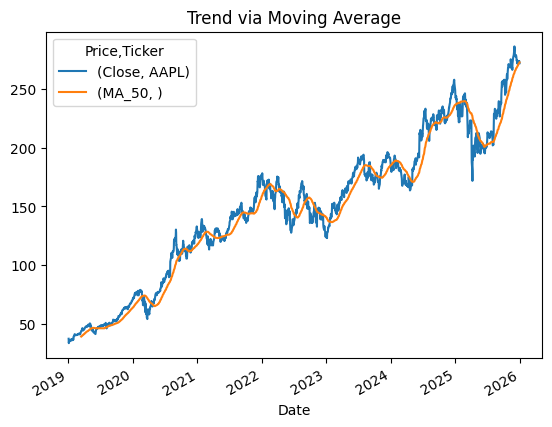

In [ ]:
# Simple trend using moving average
data["MA_50"] = data["Close"].rolling(window=50).mean()

data[["Close", "MA_50"]].plot(title="Trend via Moving Average")
plt.show()

**Strong long-term uptrend:**
- The price keeps making higher highs and higher lows from 2019 to 2026. That tells you the overall direction is clearly bullish.

**50-day moving average acts as a trend guide:**

- The price stays above the MA most of the time. When it dips below, those periods line up with short-term corrections rather than full trend reversals.

**Pullbacks are temporary:**
- Each time the price falls toward or slightly below the moving average, it eventually recovers and continues upward. This suggests buyers step in near the MA.

**Momentum confirmation:**
- When the price is above the moving average and the MA itself is sloping upward, momentum is strong. That’s what dominates most of the chart.

**Recent period (right side):**
- The price is again above the moving average after a pullback, which often signals a trend continuation rather than weakness.

**Insight:**

The trend is **strong and healthy**. The moving average acts as support and helps confirm continuation rather than signaling a reversal.

**What is a Moving Average (MA)?**

A Moving Average is a technical indicator that calculates the average price of an asset over a specific number of past periods. It is called "moving" because the average is recalculated every time a new data point (a new day's Close) becomes available.

**How it works:**

If you want a 5-day Moving Average:
1. Add the closing prices of the last 5 days.
2. Divide by 5.
3. Tomorrow, drop the oldest day and add today's new close.

$$MA = \frac{P_1 + P_2 + \dots + P_n}{n}$$

**Seasonality** refers to patterns that repeat at fixed intervals, such as:

- higher trading volume on specific days

- end-of-month effects

- quarterly business cycles

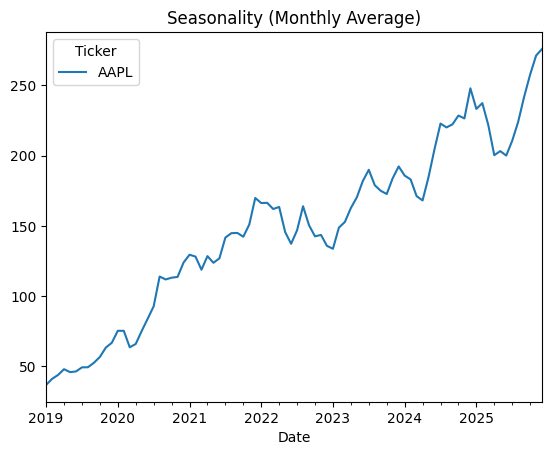

In [ ]:
# Monthly average closing price
monthly_avg = data["Close"].resample("ME").mean()

monthly_avg.plot(title="Seasonality (Monthly Average)")
plt.show()

- The chart shows a consistent upward seasonal pattern over time.

- Monthly averages rise year by year, indicating long-term growth dominates seasonality.

- Short-term dips appear, but they are temporary and repeat within an overall rising structure.

- No strong month-specific drops break the trend, which means seasonal effects are mild compared to the trend.

**Insight:**

**Seasonality** exists, but the trend is the main driver. Monthly fluctuations are small relative to the steady upward movement, making this asset more trend-driven than season-driven.

**Noise**

**Noise** is the random, unpredictable part of the series. It does not follow a clear pattern and often hides the underlying signal.

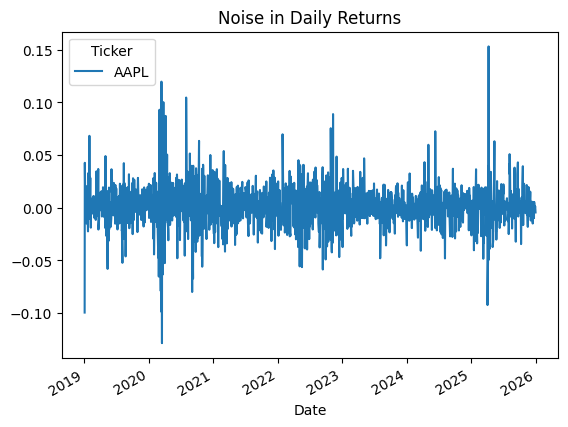

In [ ]:
# Daily returns highlight noise
returns = data["Close"].pct_change()

returns.plot(title="Noise in Daily Returns")
plt.show()

- Daily returns fluctuate randomly around zero, showing no clear short-term direction.

- Most movements are small, which means normal day-to-day noise dominates.

- Occasional large spikes appear, indicating sudden volatility events.

- Positive and negative swings are balanced, so daily returns are hard to predict.

**Insight:**

Short-term price changes are mostly noise. Meaningful signals come from longer-term trends, not daily fluctuations.

**Stationarity Test (ADF)**

Before modeling, we check whether the data is stationary using the Augmented Dickey-Fuller (ADF) test.

- Purpose: Test if the time series has a stable mean and variance over time.

- Null hypothesis: The data is non-stationary.

- Decision rule: If the p-value < 0.05, reject the null hypothesis.

- Conclusion: A p-value below 0.05 means the series is stationary and ready for modeling.

A stationary time series has:

- constant mean

- constant variance

- stable autocorrelation over time

Most raw financial price series are **not stationary.**

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
result = adfuller(data["Close"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.7497013802727425
p-value: 0.8334524805247412


If the **p-value** is high, the series is likely non-stationary.


**Conclusion:**

The p-value is much greater than 0.05, so we **fail to reject the null hypothesis**.

The series is **non-stationary** and not suitable for most time-series models.


**Common fixes:**

- differencing

- log returns

- detrending

**Simple Returns vs. Log Returns**

- Simple return measures the percentage change from one period to the next.

  It answers: How much did the price grow or fall relative to yesterday?

$$\text{Simple Return:} R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

- Log return measures the continuous rate of change using the natural log.

  It answers: What is the continuously compounded return?

$$\text{Log Return:} r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

**When to use what:**

- Use simple returns for reporting performance and portfolio gains.

- Use log returns for risk analysis, volatility modeling, and machine learning or statistical work.

In [3]:
# Make series more stationary
import numpy as np

# True log returns
log_returns = np.log(data["Close"] / data["Close"].shift(1)).dropna()
log_returns

Ticker,AAPL
Date,
2019-01-03,-0.104924
2019-01-04,0.041803
2019-01-07,-0.002228
2019-01-08,0.018884
2019-01-09,0.016839
...,...
2025-12-24,0.005310
2025-12-26,-0.001498
2025-12-29,0.001316


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# 1. Run the ADF Test
result = adfuller(log_returns)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')


ADF Statistic: -13.6091
p-value: 0.0000


**Conclusion**:

The p-value is well below 0.05, so we reject the null hypothesis.

The series is stationary and ready for modeling.

Taking log returns removes the trend and stabilizes variance. This transforms the price series from non-stationary to stationary, which is a critical step before time-series modeling.

**Distribution Check (Histogram)**

A histogram of returns helps us understand how returns are distributed.

- In practice, stock returns rarely follow a perfect normal distribution.

- They often show fat tails, meaning extreme gains or losses occur more frequently than a bell curve suggests.

- This behavior reflects higher risk during rare events, sometimes called Black Swan events.

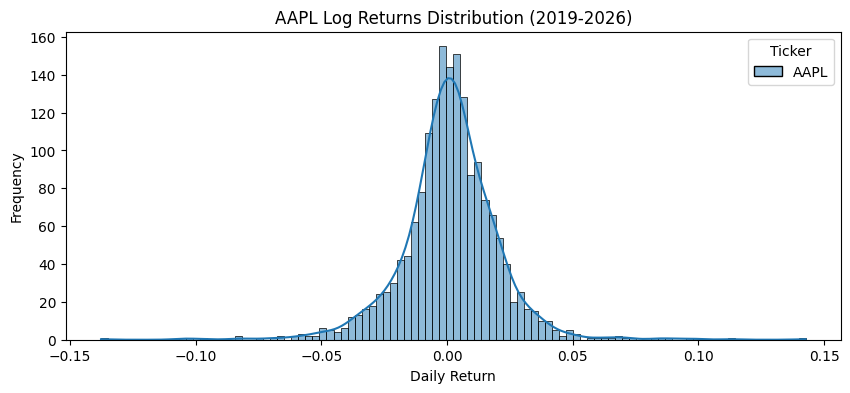

In [5]:
# 2. Visualize the Distribution
plt.figure(figsize=(10, 4))
sns.histplot(log_returns, kde=True, color='teal', bins=100)
plt.title('AAPL Log Returns Distribution (2019-2026)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

- **Peak (Stability):** Most daily price changes cluster around 0%, showing Apple is a relatively stable, blue-chip stock.

- **Shape (Symmetry):** The distribution is fairly balanced on both sides, meaning small gains and small losses are equally likely on a typical day.

- **Tails (Risk):** The extended ends of the distribution are fat tails. They represent rare but extreme moves, such as sharp drops or sudden surges, which occur more often than a normal bell curve would predict.

**Apple** is stable most days, but extreme events, while rare, are real and must be considered in risk analysis.

####**3.3 Basic Time Series Techniques**

At the beginner level, the goal is **not** to build fancy models. It’s to understand the data, transform it correctly, and create useful features. Most performance gains in finance come from feature engineering, not model complexity.

**1. Rolling Statistics**

Rolling metrics help you see how behavior changes over time.

**Rolling Mean and Rolling Standard Deviation**

- Smooth short-term noise

- Reveal local trends and volatility

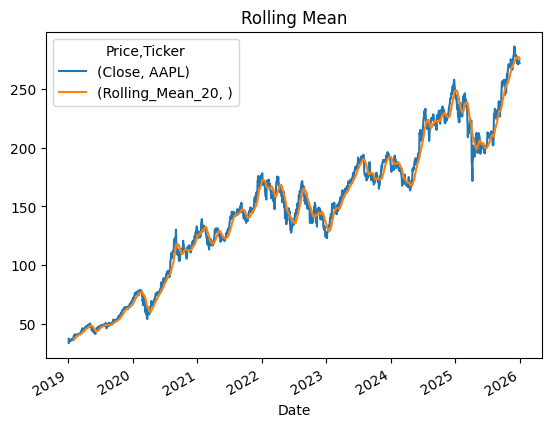

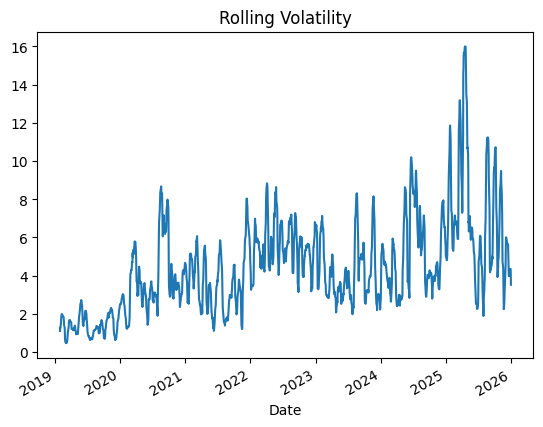

In [6]:
data["Rolling_Mean_20"] = data["Close"].rolling(window=20).mean()
data["Rolling_Std_20"] = data["Close"].rolling(window=20).std()

data[["Close", "Rolling_Mean_20"]].plot(title="Rolling Mean")
plt.show()

data["Rolling_Std_20"].plot(title="Rolling Volatility")
plt.show()

**2. Differencing (Remove Trend)**

Differencing subtracts the previous value from the current one.
This helps remove trend and makes the series more stationary.

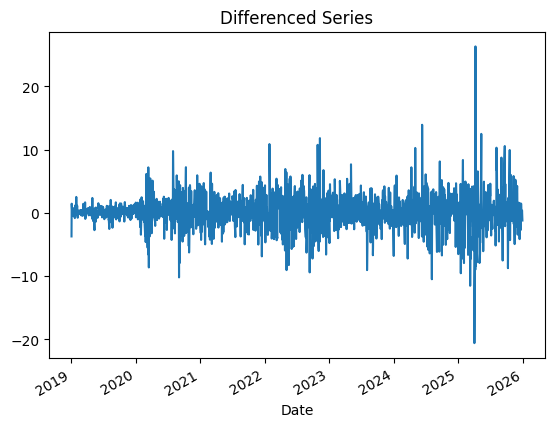

In [7]:
data["Diff_Close"] = data["Close"].diff()

data["Diff_Close"].plot(title="Differenced Series")
plt.show()

In finance:

- Prices → usually non-stationary

- Returns (differences or percentage change) → closer to stationary

In [3]:
data["Returns"] = data["Close"].pct_change()

**3. Lag Features**

Lag features turn time series into a supervised learning problem.

**Examples:**

- Yesterday’s price

- Last week’s return

- Last month’s volatility

In [9]:
# Lagged prices
data["Lag_1"] = data["Close"].shift(1)
data["Lag_5"] = data["Close"].shift(5)
data["Lag_20"] = data["Close"].shift(20)

# Lagged returns
data["Return_Lag_1"] = data["Returns"].shift(1)

These features are the backbone of:

- regression models

- tree-based models

- basic ML forecasting setups

####**3.3.1 ARIMA**

**ARIMA** (AutoRegressive Integrated Moving Average) is the "Swiss Army Knife" of time series forecasting. It’s a statistical model that looks at a stock's past behavior to predict its future path.

**The Three Components (p, d, q):** An ARIMA model is defined by three parameters: (p, d, q).

- **AR (p) - Autoregression:** This part models how the past influences the present.

    - It assumes today’s value depends on previous values of the same series.

**In simple terms:**

>What happened yesterday (or last week) still matters today.

- p = how many past time steps you look back

- Example: AR(1) uses yesterday’s value only

**AR** terms often capture short-term momentum or mean reversion, especially in returns.


This part makes the data easier to model by removing trends.

Differencing means:

subtract today’s value from yesterday’s value

repeat until the series becomes stationary

Why this matters:

raw prices usually trend over time

AR and MA assume stable statistics

So:

Differencing removes trends and turns prices into changes or returns.

d = 0: no differencing (already stationary, like returns)

d = 1: first difference (common for prices)

MA: dependence on past errors

At beginner level:

Understand why it exists

Do not tune aggressively

Use it mainly to learn stationarity and lag structure

In [7]:
from statsmodels.tsa.arima.model import ARIMA

series = data["Returns"].asfreq("B").dropna()

model = ARIMA(series, order=(1, 0, 1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                 1759
Model:                 ARIMA(1, 0, 1)   Log Likelihood                4430.579
Date:                Thu, 26 Feb 2026   AIC                          -8853.157
Time:                        08:32:57   BIC                          -8831.267
Sample:                             0   HQIC                         -8845.067
                               - 1759                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.000      2.944      0.003       0.000       0.002
ar.L1         -0.3947      0.154     -2.556      0.011      -0.697      -0.092
ma.L1          0.3155      0.159      1.986      0.0